# SI7016 — Sesión 4 · — Laboratorio: Redes Neuronales en NLP (GPU T4)
## De self-attention a BERT y GPT/LLMs abiertos con Hugging Face y LangChain

**Tema:** Redes neuronales para NLP — del mecanismo de atención al encoder (BERT) y al decoder (GPT/LLMs)

> Complementa la lectura **Lecture04a-RedesNeuronalesNLP.pptx**: primero implementamos desde cero la atención y el bloque Transformer que se explicaron ahí, y luego los usamos "en producción" a través de modelos pre-entrenados de Hugging Face.

> Este notebook está diseñado para ejecutarse en Google Colab con **NVIDIA T4 (16GB)**.


### Actividades

0. Implementar **self-attention, multi-head attention, positional encoding y máscara causal** desde cero (NumPy), replicando las fórmulas de la Sesión 4.
1. Construir y comparar representaciones (TF‑IDF vs embeddings neuronales).
2. Entender y usar embeddings contextuales con BERT (token embeddings) y sus aplicaciones.
3. Ejecutar un LLM abierto estilo GPT (decoder‑only) para generación y tareas.
4. Ejemplo básico de un RAG (retrieve → prompt → generate) usando embeddings + LangChain.
5. Mini‑reto: comparar estrategias de retrieval y justificar decisiones.


In [1]:
# Instalar dependencias (puede que ya las tenga tu ambiente, tipo google colab)

!pip -q install -U "transformers>=4.41" "datasets>=2.19" "accelerate>=0.30" "sentence-transformers>=3.0"     "scikit-learn>=1.3" "pandas>=2.0" "matplotlib>=3.7"     "langchain>=0.2" "langchain-community>=0.2" "langchain-core>=0.2"

# Reinstall pyarrow and datasets to resolve potential binary incompatibility issues
!pip uninstall -y pyarrow datasets
!pip install -U pyarrow datasets

# (Opcional) Cuantización 4-bit para modelos más pesados.
!pip -q install -U bitsandbytes

Found existing installation: pyarrow 25.0.1
Uninstalling pyarrow-25.0.1:
  Successfully uninstalled pyarrow-25.0.1
Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1
  Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl (50.1 MB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [2]:
import os, re, math, json, textwrap
import numpy as np
import pandas as pd

import torch
from sklearn.metrics.pairwise import cosine_similarity

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


---

## 1) Fundamentos: Self-Attention y Transformer desde cero

Antes de usar BERT y GPT como "cajas negras" pre-entrenadas, vamos a implementar el mecanismo que las hace funcionar: **scaled dot-product attention** (Vaswani et al., 2017), tal como se explicó en la Sesión 4 (Lecture04a-RedesNeuronalesNLP).

Comprobar:

- La fórmula exacta Atención(Q, K, V) = softmax(Q Kᵀ / √dk) · V, implementada en NumPy.
- Los pesos de atención como un heatmap, replicando el ejemplo de "El gato que está en el tejado está asustado" visto en la lectura.
- Multi-head attention: dividir Q, K, V en h cabezas y calcular atención en paralelo.
- Positional encoding sinusoidal — por qué la atención por sí sola no conoce el orden.
- La máscara causal (masked self-attention) que usa GPT para generar texto token por token.

> Esta es una implementación mínima con fines pedagógicos — la librería `transformers` que usaremos después implementa versiones optimizadas de exactamente estos mismos mecanismos.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V, mask=None):
    """Atención(Q, K, V) = softmax( Q Kᵀ / √dk ) · V  (Vaswani et al., 2017)"""
    dk = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(dk)          # (n, n) similitudes producto-punto
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    scores = scores - scores.max(axis=-1, keepdims=True)  # estabilidad numérica
    weights = np.exp(scores)
    weights = weights / weights.sum(axis=-1, keepdims=True)
    output = weights @ V                     # combinación ponderada de Values
    return output, weights

# Ejemplo de la lectura: "El gato que está en el tejado está asustado"
tokens = ["El", "gato", "que", "está", "en", "el", "tejado", "está", "asustado"]

np.random.seed(7)
d = 8  # dimensión de embedding (juguete; en un Transformer real sería 512 o más)
X = np.random.randn(len(tokens), d)  # embeddings de entrada (aleatorios, solo ilustrativo)

# En un Transformer real, WQ, WK, WV se aprenden por descenso de gradiente
WQ = np.random.randn(d, d) * 0.5
WK = np.random.randn(d, d) * 0.5
WV = np.random.randn(d, d) * 0.5

Q, K, V = X @ WQ, X @ WK, X @ WV
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Forma de Q, K, V:", Q.shape)
print("Forma de la matriz de pesos de atención:", attn_weights.shape)
print("Suma de cada fila de la matriz de atención (debe ser 1.0):", attn_weights.sum(axis=1).round(3))


Forma de Q, K, V: (9, 8)
Forma de la matriz de pesos de atención: (9, 9)
Suma de cada fila de la matriz de atención (debe ser 1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


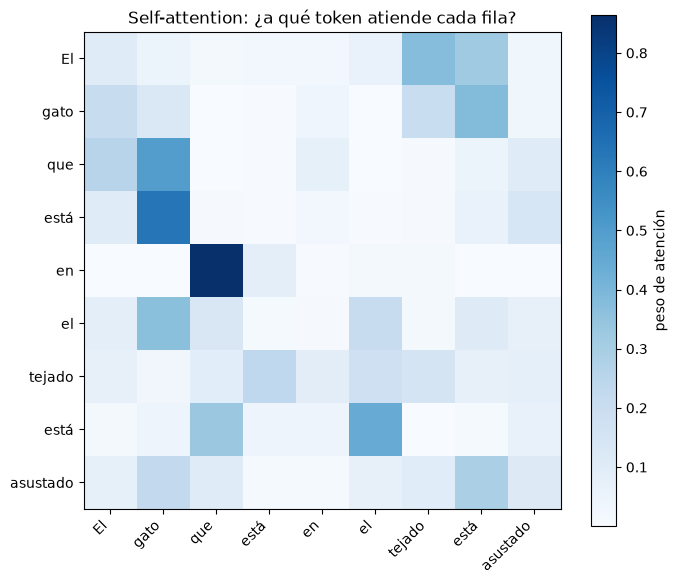

      está: 0.290
      gato: 0.226
  asustado: 0.113
       que: 0.103
    tejado: 0.102
        El: 0.073
        el: 0.069
        en: 0.013
      está: 0.012


In [4]:
plt.figure(figsize=(7, 6))
plt.imshow(attn_weights, cmap="Blues")
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.yticks(range(len(tokens)), tokens)
plt.colorbar(label="peso de atención")
plt.title("Self-attention: ¿a qué token atiende cada fila?")
plt.tight_layout()
plt.show()

# Fila de "asustado" (última palabra): ¿a qué token atiende más?
idx_asustado = tokens.index("asustado")
for t, w in sorted(zip(tokens, attn_weights[idx_asustado]), key=lambda x: -x[1]):
    print(f"{t:>10s}: {w:.3f}")


Responda:

1) Con estos embeddings aleatorios, ¿a qué token atiende más "asustado"? ¿Es razonable? ¿Por qué la respuesta puede no coincidir con la intuición lingüística?
2) ¿Qué garantiza matemáticamente que cada fila de la matriz de atención sume 1.0?
3) ¿Qué pasaría si NO dividiéramos por √dk antes del softmax? (pista: piensa qué le pasa al softmax cuando los valores de entrada son muy grandes)


### Multi-head attention

d_model se reparte en h cabezas de dimensión dk = d_model / h. Cada cabeza tiene sus propias matrices WQ, WK, WV y calcula su propia atención en paralelo; luego las h salidas se concatenan y se proyectan con WO.

Salida multi-head: (9, 32)  (4 cabezas de dk = 8 cada una)


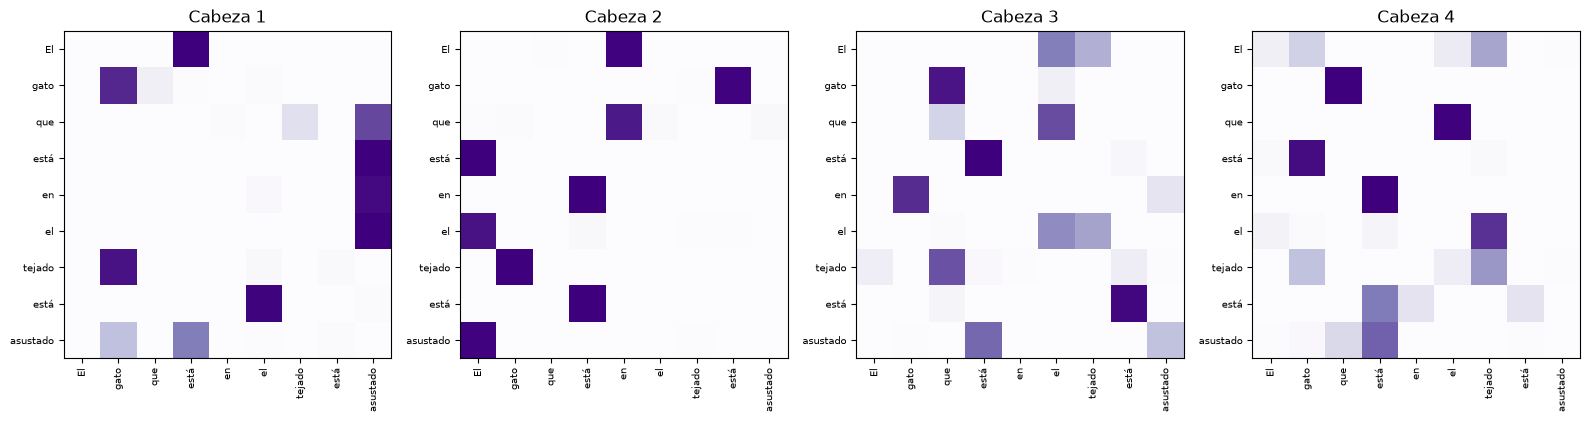

In [5]:
def multi_head_attention(X, num_heads, d_model, seed=0):
    """Divide d_model en `num_heads` cabezas de tamaño dk = d_model/num_heads,
    calcula atención en paralelo en cada cabeza y concatena + proyecta con WO."""
    assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
    dk = d_model // num_heads
    rng = np.random.default_rng(seed)

    heads_out, heads_weights = [], []
    for h in range(num_heads):
        WQh = rng.normal(scale=0.5, size=(d_model, dk))
        WKh = rng.normal(scale=0.5, size=(d_model, dk))
        WVh = rng.normal(scale=0.5, size=(d_model, dk))
        Qh, Kh, Vh = X @ WQh, X @ WKh, X @ WVh
        out_h, w_h = scaled_dot_product_attention(Qh, Kh, Vh)
        heads_out.append(out_h)
        heads_weights.append(w_h)

    concat = np.concatenate(heads_out, axis=-1)   # (n, d_model)
    WO = rng.normal(scale=0.5, size=(d_model, d_model))
    output = concat @ WO
    return output, heads_weights

d_model = 32
X2 = np.random.randn(len(tokens), d_model)
mh_out, mh_weights = multi_head_attention(X2, num_heads=4, d_model=d_model)
print("Salida multi-head:", mh_out.shape, " (4 cabezas de dk =", d_model // 4, "cada una)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for h, ax in enumerate(axes):
    ax.imshow(mh_weights[h], cmap="Purples")
    ax.set_title(f"Cabeza {h + 1}")
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=7)
plt.tight_layout()
plt.show()


Responda: con pesos aleatorios cada cabeza "atiende" de forma distinta. En un Transformer ya entrenado, ¿qué se espera que aprenda cada cabeza? (revise en la lectura la sección "¿Qué aprende cada cabeza? Un ejemplo de ambigüedad")

### Positional encoding

`PE(pos, 2i) = sin( pos / 10000^(2i/d) )` &nbsp;&nbsp; `PE(pos, 2i+1) = cos( pos / 10000^(2i/d) )` (codificación posicional sinusoidal, Vaswani et al., 2017)

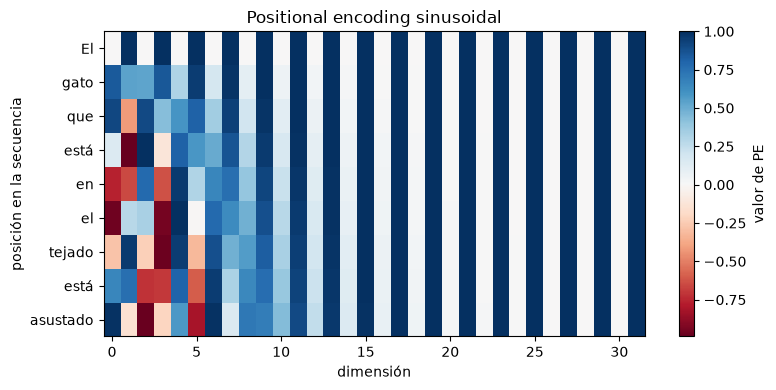

In [6]:
def positional_encoding(seq_len, d_model):
    """PE(pos, 2i) = sin(pos / 10000^(2i/d))   PE(pos, 2i+1) = cos(pos / 10000^(2i/d))"""
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

pe = positional_encoding(seq_len=len(tokens), d_model=32)

plt.figure(figsize=(8, 4))
plt.imshow(pe, cmap="RdBu", aspect="auto")
plt.xlabel("dimensión")
plt.ylabel("posición en la secuencia")
plt.yticks(range(len(tokens)), tokens)
plt.colorbar(label="valor de PE")
plt.title("Positional encoding sinusoidal")
plt.tight_layout()
plt.show()


Responda: sin este vector posicional, la self-attention es invariante al orden de los tokens ("perro muerde hombre" = "hombre muerde perro" para el modelo). Explica con tus palabras por qué sumar PE(pos) al embedding de entrada resuelve este problema.

### Máscara causal (masked self-attention)

Al generar el token t, el modelo no puede "ver" los tokens t+1, t+2, … Esto se implementa poniendo −∞ en las posiciones futuras de la matriz de similitudes, antes del softmax — así entrena y genera GPT, token por token.

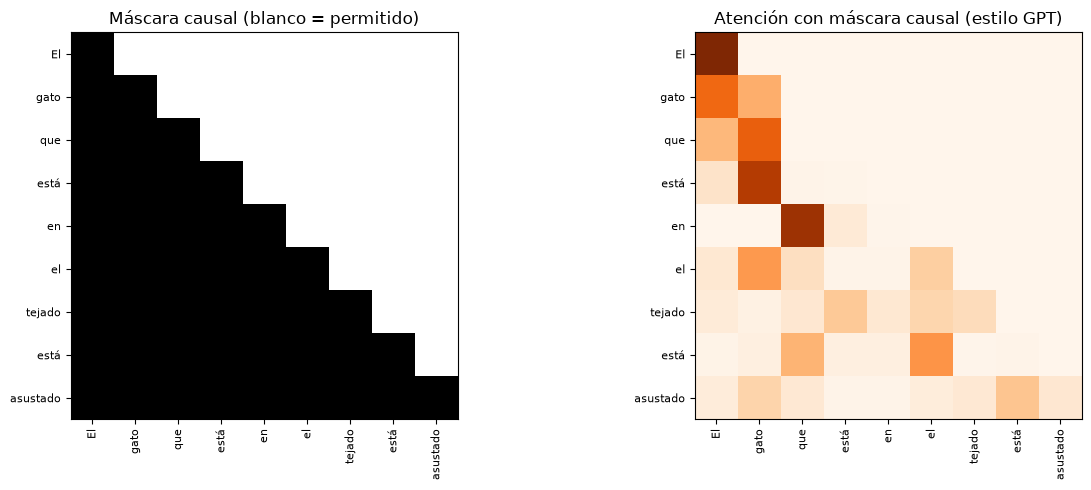

¿Alguna fila atiende al futuro?  False


In [7]:
def causal_mask(seq_len):
    """Máscara triangular inferior: cada posición i solo puede atender a j <= i."""
    return np.tril(np.ones((seq_len, seq_len), dtype=bool))

mask = causal_mask(len(tokens))
_, causal_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(mask, cmap="Greys")
axes[0].set_title("Máscara causal (blanco = permitido)")
axes[1].imshow(causal_weights, cmap="Oranges")
axes[1].set_title("Atención con máscara causal (estilo GPT)")
for ax in axes:
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=8)
plt.tight_layout()
plt.show()

futuro = causal_weights[np.triu_indices(len(tokens), k=1)]
print("¿Alguna fila atiende al futuro? ", bool((futuro > 1e-9).any()))


Responda: compara la matriz de atención "completa" (bidireccional) con la "causal" (triangular). ¿Cuál usa BERT y cuál usa GPT? ¿Por qué GPT no podría usar atención bidireccional para generar texto token por token?

---

## 2) Representaciones de texto: TF‑IDF vs Embeddings neuronales

### ¿Qué es un embedding y para qué sirve?

Vamos a comparar:
- TF‑IDF (clásico, basado en conteos de vocabulario)
- Sentence embeddings (neuronales, semánticos)


In [8]:
# ejemplo con este dataset básico, pero en el reto podrá utilizar un dataset más completo como ag_news
texts = [
    "El café liofilizado preserva aroma y sabor.",
    "La liofilización reduce la humedad del café.",
    "Me gusta el espresso por su sabor intenso.",
    "La Universidad EAFIT está en Medellín.",
    "BERT es un modelo encoder para comprensión de texto.",
    "GPT es un modelo decoder para generación de texto.",
    "El secado por congelación conserva compuestos volátiles.",
    "Los transformers usan atención para modelar contexto."
]

pairs_to_compare = [
    (0, 1),  # café liofilizado vs liofilización
    (0, 6),  # café liofilizado vs secado por congelación (sinónimo aproximado)
    (4, 5),  # BERT vs GPT (relacionados pero distintos)
    (0, 3),  # café vs EAFIT (no relacionados)
]

len(texts), texts[:2]

(8,
 ['El café liofilizado preserva aroma y sabor.',
  'La liofilización reduce la humedad del café.'])

In [9]:
# representaciones en tfidf y realización de función de similitud coseno
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(texts)
cos_tfidf = cosine_similarity(X)

def show_pairs(sim_matrix, name):
    print(f"\n== {name} ==")
    for i,j in pairs_to_compare:
        print(f"({i},{j}) {sim_matrix[i,j]:.3f} | '{texts[i]}'  <->  '{texts[j]}'")

show_pairs(cos_tfidf, "TF-IDF cosine")

# RESPONDA: CONCLUSIONES DE ACUERDO A LOS RESULTADOS


== TF-IDF cosine ==
(0,1) 0.115 | 'El café liofilizado preserva aroma y sabor.'  <->  'La liofilización reduce la humedad del café.'
(0,6) 0.094 | 'El café liofilizado preserva aroma y sabor.'  <->  'El secado por congelación conserva compuestos volátiles.'
(4,5) 0.574 | 'BERT es un modelo encoder para comprensión de texto.'  <->  'GPT es un modelo decoder para generación de texto.'
(0,3) 0.000 | 'El café liofilizado preserva aroma y sabor.'  <->  'La Universidad EAFIT está en Medellín.'


In [10]:
# utilizar un modelo de embeddings para representrar las oraciones del dataset texts
from sentence_transformers import SentenceTransformer

# Modelo multi-lingüe liviano y muy efectivo para similitud semántica
st_model_id = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
st = SentenceTransformer(st_model_id)

E = st.encode(texts, normalize_embeddings=True)
cos_st = E @ E.T

show_pairs(cos_st, "Sentence-Transformers cosine")
# RESPONDA: CONCLUSIONES DE ACUERDO A LOS RESULTADOS

# Busque en la libreria de modelos de huggingface otros modelos de embeddgins y compare resultados

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


== Sentence-Transformers cosine ==
(0,1) 0.718 | 'El café liofilizado preserva aroma y sabor.'  <->  'La liofilización reduce la humedad del café.'
(0,6) 0.218 | 'El café liofilizado preserva aroma y sabor.'  <->  'El secado por congelación conserva compuestos volátiles.'
(4,5) 0.448 | 'BERT es un modelo encoder para comprensión de texto.'  <->  'GPT es un modelo decoder para generación de texto.'
(0,3) 0.019 | 'El café liofilizado preserva aroma y sabor.'  <->  'La Universidad EAFIT está en Medellín.'


### Responda de forma corta (3–5 líneas)
1) ¿Qué pares mejoraron más al pasar de TF‑IDF a embeddings?  
2) ¿Qué limita a TF‑IDF en semántica?  
3) ¿Qué “tipo de embedding” conviene para Recuperación semántico?

---

## 3) BERT como encoder: embeddings contextuales y aplicaciones

Comprobar:

- Como cambia el embedding de una misma palabra según el contexto.
- Uso práctico de BERT en las tareas de NER y clasificación con Hugging Face pipelines.

In [11]:
from transformers import AutoTokenizer, AutoModel

# modelo BERT más basico
bert_id = "bert-base-multilingual-cased"
tok = AutoTokenizer.from_pretrained(bert_id)
bert = AutoModel.from_pretrained(bert_id)

bert.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
bert.to(device)

bert_id, device

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


('bert-base-multilingual-cased', 'cuda')

### Embedding de una palabra depende del contexto

Ejemplo: la palabra “banco” (financiero vs asiento).
Vamos a extraer el embedding del token (promediando sub‑tokens si aplica) y comparar.

In [12]:
def token_embedding(sentence, target):
    inputs = tok(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = bert(**inputs).last_hidden_state[0]  # (seq_len, hidden)
    tokens = tok.convert_ids_to_tokens(inputs["input_ids"][0].tolist())

    # Encuentra posiciones de sub-tokens que contienen la palabra objetivo
    idx = [i for i,t in enumerate(tokens) if target in t.lower()]
    if not idx:
        raise ValueError(f"No encontré '{target}' en tokens: {tokens}")

    emb = out[idx].mean(dim=0).detach().cpu().numpy()
    emb = emb / np.linalg.norm(emb)
    return emb, tokens

s1 = "El banco central anunció una nueva medida económica."
s2 = "Me senté en el banco del parque para descansar."
#s2 = "Me senté en el banco del parque para descansar de camino al banco."

e1, t1 = token_embedding(s1, "banco")
e2, t2 = token_embedding(s2, "banco")

cos = float(e1 @ e2)
print("Cosine(banco_financiero, banco_asiento) =", round(cos, 3))
print("Tokens s1:", t1)
print("Tokens s2:", t2)

Cosine(banco_financiero, banco_asiento) = 0.585
Tokens s1: ['[CLS]', 'El', 'banco', 'central', 'anunció', 'una', 'nueva', 'medida', 'económica', '.', '[SEP]']
Tokens s2: ['[CLS]', 'Me', 'sent', '##é', 'en', 'el', 'banco', 'del', 'parque', 'para', 'des', '##cans', '##ar', '.', '[SEP]']


Responda:  
¿Por qué BERT puede producir embeddings distintos para la misma palabra en diferentes oraciones?

### NER con Hugging Face pipeline (modelo ya entrenado)

usar un modelo multilingüe para NER y ver qué entidades detecta.

In [13]:
from transformers import pipeline

ner = pipeline(
    "ner",
    model="Davlan/bert-base-multilingual-cased-ner-hrl",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

text_ner = "La Universidad EAFIT está en Medellín. Google lanzó BERT en 2018 y OpenAI lanzó GPT-3 en 2020."
entities = ner(text_ner)
pd.DataFrame(entities)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,entity_group,score,word,start,end
0,ORG,0.998845,Universidad EAFIT,3,20
1,LOC,0.999850,Medellín,29,37
2,ORG,0.999735,Google,39,45
3,ORG,0.999549,OpenAI,67,73


Análisis:  
1) ¿Qué entidades detectó bien?  
2) ¿Qué errores observas y cómo los explicarías?  
3) ¿Qué harías para mejorar NER en un dominio específico (ej. medicina, legal, ingeniería)?
4) usa otras oraciones para verificar aciertos y errores

### Clasificación (análisis de sentimientos) con pipeline

Usaremos un modelo multilingüe pre‑entrenado para sentimiento.

In [14]:
clf = pipeline(
    "text-classification",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0 if torch.cuda.is_available() else -1
)

samples = [
    "Este curso es excelente, la explicación de transformers fue muy clara.",
    "No me gustó el laboratorio, estuvo confuso y demasiado largo.",
    "La liofilización del café conserva el aroma de manera sorprendente."
]
pd.DataFrame([{"text": s, **clf(s)[0]} for s in samples])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,label,score
0,"Este curso es excelente, la explicación de tra...",5 stars,0.645748
1,"No me gustó el laboratorio, estuvo confuso y d...",2 stars,0.568997
2,La liofilización del café conserva el aroma de...,5 stars,0.479623


Responde:   
¿Por qué BERT suele ser más fuerte en comprensión (clasificación/NER) que en generación?

---

## 4) LLMs abiertos (Hugging Face)

- generación autoregresiva (continuación de texto)
- prompts “cero‑shot” vs “few‑shot”
- control de formato (bullets / JSON)

> Modelo sugerido para T4: Qwen2.5 1.5B Instruct (ligero) o Phi‑3 mini.  
> cuantización 4‑bit para evitar OOM.

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig

# Modelo abierto liviano: para nvidia T4.
# Otro modelo: "microsoft/phi-3-mini-4k-instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

llm_id = "Qwen/Qwen2.5-1.5B-Instruct"

tok_llm = AutoTokenizer.from_pretrained(llm_id, use_fast=True)

if torch.cuda.is_available():
    llm = AutoModelForCausalLM.from_pretrained(llm_id, device_map="auto",
                                               quantization_config=bnb_config)

else:
    llm = AutoModelForCausalLM.from_pretrained(llm_id)

gen = pipeline(
    "text-generation", # tarea
    model=llm,
    tokenizer=tok_llm,
    device_map="auto" if torch.cuda.is_available() else None
)

llm_id

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

'Qwen/Qwen2.5-1.5B-Instruct'

In [16]:
# Prompt 1: cero-shot
prompt_0 = "Resume en 5 puntos: El café liofilizado preserva aroma y reduce humedad, mejorando estabilidad y vida útil."

out0 = gen(prompt_0, max_new_tokens=120, do_sample=True, temperature=0.7)
print(out0[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Resume en 5 puntos: El café liofilizado preserva aroma y reduce humedad, mejorando estabilidad y vida útil. Los procesos de fumigación o desinfección pueden afectar el contenido químico del café.
En resumen, los cafés liofilizados son una opción saludable para aquellos que buscan un equilibrio entre calidad y durabilidad.

Aquí tienes un breve resumen con sus cinco puntos principales:

1. **Preservación del Aroma**: La técnica de fumigación puede reducir o eliminar algunos componentes aromáticos, alterando la percepción olfativa del café.

2. **Control de Humedad**: Las técnicas


In [17]:
# Prompt 2: few-shot (ejemplo de formato)
prompt_fs = """Tarea: Resume en 5 puntos.

Ejemplo:
Texto: La acuarela urbana combina dibujo y pintura rápida en exteriores.
Resumen:
- Técnica rápida en exteriores
- Combina dibujo y color
- Enfatiza observación
- Requiere síntesis visual
- Útil para registrar escenas

Ahora:
Texto: El café liofilizado preserva aroma y reduce humedad, mejorando estabilidad y vida útil.
Resumen:
"""

out1 = gen(prompt_fs, max_new_tokens=150, do_sample=True, temperature=0.6)
print(out1[0]["generated_text"])

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tarea: Resume en 5 puntos.

Ejemplo:
Texto: La acuarela urbana combina dibujo y pintura rápida en exteriores.
Resumen:
- Técnica rápida en exteriores
- Combina dibujo y color
- Enfatiza observación
- Requiere síntesis visual
- Útil para registrar escenas

Ahora:
Texto: El café liofilizado preserva aroma y reduce humedad, mejorando estabilidad y vida útil.
Resumen:
- Preserva aroma
- Reduce humedad
- Mejora estabilidad
- Aumenta vida útil
- Óptimo para alimentos y bebidas


Responde:  
¿Qué cambió al usar few‑shot? ¿El modelo siguió mejor el formato? ¿Por qué?

---

## 5) Mini‑RAG local: Embeddings + Retrieval + (LangChain Prompt)

RAG mínimo con:
- Chunks pequeños (corpus local)
- Embeddings de sentence-transformers
- Recuperación top‑k por coseno
- Prompt con LangChain (solo para estructura)

> Esto NO usa OpenSearch ni FAISS: es el “mínimo viable” para comprender el flujo.

In [18]:
# Mini-corpus (puedes reemplazarlo por tus propios textos o de de datasets de texto de huggingface)
chunks = [
    "La liofilización es un proceso de secado por congelación que elimina agua por sublimación.",
    "En café liofilizado, la reducción de humedad mejora la estabilidad y vida útil del producto.",
    "El proceso busca conservar aroma y compuestos volátiles del café mediante bajas temperaturas.",
    "BERT es un encoder basado en transformers, útil para clasificación, NER y extracción de información.",
    "GPT y LLMs decoder-only son fuertes en generación y seguimiento de instrucciones.",
    "Los embeddings semánticos permiten búsqueda por significado, no solo por coincidencia de palabras.",
    "Transformers usan self-attention para capturar dependencias largas y paralelizar entrenamiento.",
    "En RAG, recuperamos fragmentos relevantes y luego generamos respuesta con un LLM usando ese contexto."
]

E_chunks = st.encode(chunks, normalize_embeddings=True)

def retrieve(query, k=3):
    q = st.encode([query], normalize_embeddings=True)
    scores = (E_chunks @ q.T).ravel()
    idx = np.argsort(scores)[::-1][:k]
    return [(chunks[i], float(scores[i])) for i in idx]

question = "¿Qué ventajas tiene la liofilización en el café?"
print(question)
retrieved = retrieve(question, k=3)
print(pd.DataFrame(retrieved, columns=["chunk", "score"]))

print(question)
question = "¿Qué desventajas tiene la liofilización en el café?"
retrieved = retrieve(question, k=3)
print(pd.DataFrame(retrieved, columns=["chunk", "score"]))

¿Qué ventajas tiene la liofilización en el café?
                                               chunk     score
0  En café liofilizado, la reducción de humedad m...  0.669799
1  El proceso busca conservar aroma y compuestos ...  0.646295
2  La liofilización es un proceso de secado por c...  0.244726
¿Qué ventajas tiene la liofilización en el café?
                                               chunk     score
0  El proceso busca conservar aroma y compuestos ...  0.634142
1  En café liofilizado, la reducción de humedad m...  0.600888
2  La liofilización es un proceso de secado por c...  0.251542


In [19]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_template(
"""Eres un asistente académico. Responde SOLO usando el contexto.
Si la respuesta no está en el contexto, di: "No está en el contexto proporcionado."

Contexto:
{context}

Pregunta: {question}

Respuesta en español (máx 6 líneas):
""")

context = "\n\n".join([c for c,_ in retrieved])
final_prompt = rag_prompt.format(context=context, question=question)
print(final_prompt)

Human: Eres un asistente académico. Responde SOLO usando el contexto.
Si la respuesta no está en el contexto, di: "No está en el contexto proporcionado."

Contexto:
El proceso busca conservar aroma y compuestos volátiles del café mediante bajas temperaturas.

En café liofilizado, la reducción de humedad mejora la estabilidad y vida útil del producto.

La liofilización es un proceso de secado por congelación que elimina agua por sublimación.

Pregunta: ¿Qué desventajas tiene la liofilización en el café?

Respuesta en español (máx 6 líneas):



In [20]:
# Generamos respuesta con el LLM abierto usando el prompt construido
out = gen(final_prompt, max_new_tokens=180, do_sample=False, temperature=0.0)
print(out[0]["generated_text"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Human: Eres un asistente académico. Responde SOLO usando el contexto.
Si la respuesta no está en el contexto, di: "No está en el contexto proporcionado."

Contexto:
El proceso busca conservar aroma y compuestos volátiles del café mediante bajas temperaturas.

En café liofilizado, la reducción de humedad mejora la estabilidad y vida útil del producto.

La liofilización es un proceso de secado por congelación que elimina agua por sublimación.

Pregunta: ¿Qué desventajas tiene la liofilización en el café?

Respuesta en español (máx 6 líneas):
La liofilización puede causar pérdida de sabor y textura al eliminar los compuestos volátiles del café durante el proceso de secado.

Assistant:

Liofilización puede afectar negativamente la calidad sensorial del café debido a la eliminación de compuestos volátiles importantes para su sabor y textura. Además, puede llevar a una disminución de la vida útil del producto si se reduce demasiado el contenido de agua. Sin embargo, esta técnica también perm

Responde:  
1) ¿Qué ocurre si el top‑k no incluye la información?  
2) ¿Cómo reducirías alucinaciones en un RAG real?  
3) ¿Qué componente es más importante: embeddings, retrieval, prompt o el LLM?

---

# 6) Mini‑Reto Clase
## “Embeddings para Retrieval: Sentence‑Transformers vs BERT (CLS/mean)”

**Objetivo:** comparar dos estrategias de embeddings para recuperación semántica.

### Estrategias
- A) Sentence‑Transformers (modelo ya usado)
- B) BERT embeddings artesanales o  (promedio de tokens / CLS)

### Tareas
1) Define un conjunto de preguntas sobre el corpus (8–10 preguntas).  
2) Para cada pregunta, recupera top‑3 chunks con A y con B.  
3) Define una “verdad base” simple: para cada pregunta indica el índice del chunk correcto (puede ser manual).  
4) Calcula Recall@3 para A y B.  
5) Escribe un análisis breve:
   - 2 casos donde A gana y por qué  
   - 2 casos donde B gana (si ocurre) y por qué  
   - conclusión: ¿qué usarías en una app real y por qué?
6) si tienes tiempo, usa un dataset grande de huggingface, ojala en español para QA y repite este ejercicio.

In [21]:
# Define preguntas y ground-truth (chunk correcto)
questions = [
    "¿Qué es la liofilización?",
    "¿Para qué sirve reducir la humedad en café liofilizado?",
    "¿Por qué se conservan compuestos volátiles?",
    "¿Qué es RAG en pocas palabras?",
    "¿Para qué sirve BERT?",
    "¿Para qué sirve GPT en comparación con BERT?",
    "¿Qué aportan los embeddings semánticos en búsqueda?",
    "¿Qué hace especial a self-attention en transformers?"
]

# Índice del chunk correcto (0..len(chunks)-1)
# (Puedes modificar si ajustas el corpus.)
gold = [0, 1, 2, 7, 3, 4, 5, 6]

assert len(questions) == len(gold)
len(questions)

8

In [22]:
# Estrategia A: Sentence-Transformers
E_A = st.encode(chunks, normalize_embeddings=True)

def retrieve_A(query, k=3):
    q = st.encode([query], normalize_embeddings=True)
    scores = (E_A @ q.T).ravel()
    idx = np.argsort(scores)[::-1][:k]
    return idx.tolist(), scores[idx].tolist()

# 5C) Estrategia B: BERT mean pooling (simple)
def bert_sentence_embedding(sentence):
    inputs = tok(sentence, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        out = bert(**inputs).last_hidden_state  # (1, seq, hidden)
    # mean pooling sobre tokens (excluyendo padding si existiera)
    mask = inputs["attention_mask"].unsqueeze(-1)  # (1, seq, 1)
    emb = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    emb = emb[0].detach().cpu().numpy()
    emb = emb / np.linalg.norm(emb)
    return emb

E_B = np.stack([bert_sentence_embedding(c) for c in chunks], axis=0)

def retrieve_B(query, k=3):
    q = bert_sentence_embedding(query)
    scores = E_B @ q
    idx = np.argsort(scores)[::-1][:k]
    return idx.tolist(), scores[idx].tolist()

# Prueba rápida
retrieve_A("¿Qué es RAG?", k=3), retrieve_B("¿Qué es RAG?", k=3)[:1]

(([7, 3, 5], [0.3852721154689789, 0.17964446544647217, 0.1650654673576355]),
 ([7, 6, 5],))

In [23]:
def recall_at_k(retrieved_idx, gold_idx, k=3):
    return 1.0 if gold_idx in retrieved_idx[:k] else 0.0

rows = []
for q, g in zip(questions, gold):
    idxA, _ = retrieve_A(q, k=3)
    idxB, _ = retrieve_B(q, k=3)
    rows.append({
        "question": q,
        "gold_chunk": g,
        "A_top3": idxA,
        "B_top3": idxB,
        "A_hit": recall_at_k(idxA, g, 3),
        "B_hit": recall_at_k(idxB, g, 3)
    })

df = pd.DataFrame(rows)
df

,question,gold_chunk,A_top3,B_top3,A_hit,B_hit
0,¿Qué es la liofilización?,0,"[0, 3, 1]","[0, 1, 2]",1.0,1.0
1,¿Para qué sirve reducir la humedad en café lio...,1,"[1, 2, 0]","[1, 2, 0]",1.0,1.0
2,¿Por qué se conservan compuestos volátiles?,2,"[2, 0, 7]","[2, 1, 0]",1.0,1.0
3,¿Qué es RAG en pocas palabras?,7,"[5, 7, 3]","[5, 6, 7]",1.0,1.0
4,¿Para qué sirve BERT?,3,"[3, 5, 1]","[2, 5, 1]",1.0,0.0
5,¿Para qué sirve GPT en comparación con BERT?,4,"[4, 3, 7]","[7, 5, 3]",1.0,0.0
6,¿Qué aportan los embeddings semánticos en búsq...,5,"[5, 7, 3]","[5, 3, 7]",1.0,1.0
7,¿Qué hace especial a self-attention en transfo...,6,"[6, 3, 4]","[6, 5, 4]",1.0,1.0


In [24]:
A_recall = df["A_hit"].mean()
B_recall = df["B_hit"].mean()
print("Recall@3 (A: Sentence-Transformers):", round(A_recall, 3))
print("Recall@3 (B: BERT mean pooling):", round(B_recall, 3))

Recall@3 (A: Sentence-Transformers): 1.0
Recall@3 (B: BERT mean pooling): 0.75


### Responde:

- ¿A o B para retrieval semántico y por qué?
- 2 casos donde A gana (menciona pregunta + explicación)
- 2 casos donde B gana (si aplica)
- ¿Qué cambiarías para mejorar BERT como embedding de retrieval? (pista: entrenamiento tipo sentence-transformers)